# **Data Preprocessing**

In [3]:
import pandas as pd

In [4]:
df=pd.read_csv('Adidas.csv')

In [5]:
df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,1/1/2020,Northeast,New York,New York,Men's Street Footwear,$50.00,1200,"$60,000","$30,000",50%,In-store
1,Foot Locker,1185732,1/2/2020,Northeast,New York,New York,Men's Athletic Footwear,$50.00,1000,"$50,000","$15,000",30%,In-store
2,Foot Locker,1185732,1/3/2020,Northeast,New York,New York,Women's Street Footwear,$40.00,1000,"$40,000","$14,000",35%,In-store
3,Foot Locker,1185732,1/4/2020,Northeast,New York,New York,Women's Athletic Footwear,$45.00,850,"$38,250","$13,388",35%,In-store
4,Foot Locker,1185732,1/5/2020,Northeast,New York,New York,Men's Apparel,$60.00,900,"$54,000","$16,200",30%,In-store


In [6]:
df.tail()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
9643,Foot Locker,1185732,1/24/2021,Northeast,New Hampshire,Manchester,Men's Apparel,$50.00,64,"$3,200",$896,28%,Outlet
9644,Foot Locker,1185732,1/24/2021,Northeast,New Hampshire,Manchester,Women's Apparel,$41.00,105,"$4,305","$1,378",32%,Outlet
9645,Foot Locker,1185732,2/22/2021,Northeast,New Hampshire,Manchester,Men's Street Footwear,$41.00,184,"$7,544","$2,791",37%,Outlet
9646,Foot Locker,1185732,2/22/2021,Northeast,New Hampshire,Manchester,Men's Athletic Footwear,$42.00,70,"$2,940","$1,235",42%,Outlet
9647,Foot Locker,1185732,2/22/2021,Northeast,New Hampshire,Manchester,Women's Street Footwear,$29.00,83,"$2,407",$650,27%,Outlet


In [7]:
df.shape

(9648, 13)

In [8]:
df.columns

Index(['Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Retailer          9648 non-null   object
 1   Retailer ID       9648 non-null   int64 
 2   Invoice Date      9648 non-null   object
 3   Region            9648 non-null   object
 4   State             9648 non-null   object
 5   City              9648 non-null   object
 6   Product           9648 non-null   object
 7   Price per Unit    9648 non-null   object
 8   Units Sold        9648 non-null   int64 
 9   Total Sales       9648 non-null   object
 10  Operating Profit  9648 non-null   object
 11  Operating Margin  9648 non-null   object
 12  Sales Method      9648 non-null   object
dtypes: int64(2), object(11)
memory usage: 980.0+ KB


In [10]:
numeric_cols=['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit','Operating Margin']

for i in numeric_cols:
  df[i]=(
      df[i]
      .astype(str)
      .str.replace('$','')
      .str.replace(',','')
      .str.replace('%','')
      .astype(float)
         )

df['Units Sold'] = df['Units Sold'].astype(str).str.replace(',', '').astype(float).astype(int)
df['Retailer ID']=df['Retailer ID'].astype(str)
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   object        
 1   Retailer ID       9648 non-null   object        
 2   Invoice Date      9648 non-null   datetime64[ns]
 3   Region            9648 non-null   object        
 4   State             9648 non-null   object        
 5   City              9648 non-null   object        
 6   Product           9648 non-null   object        
 7   Price per Unit    9648 non-null   float64       
 8   Units Sold        9648 non-null   int64         
 9   Total Sales       9648 non-null   float64       
 10  Operating Profit  9648 non-null   float64       
 11  Operating Margin  9648 non-null   float64       
 12  Sales Method      9648 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(7)
memory usage: 980.0+ KB


In [12]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

0


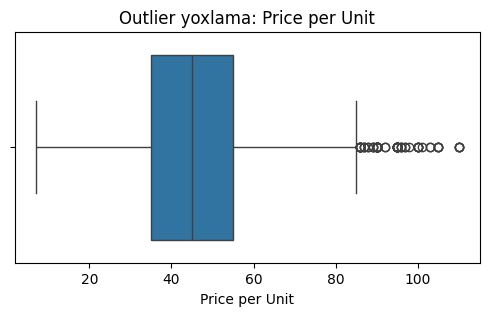

Price per Unit sütununda 81 dənə outlier tapıldı.


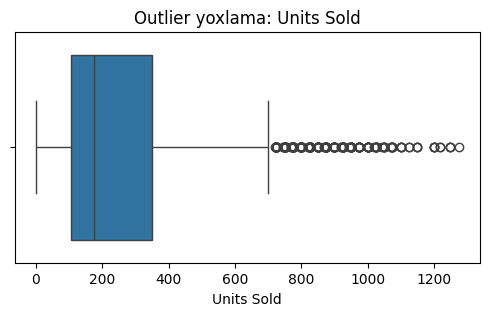

Units Sold sütununda 508 dənə outlier tapıldı.


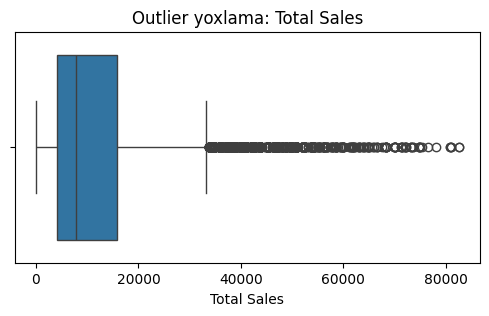

Total Sales sütununda 799 dənə outlier tapıldı.


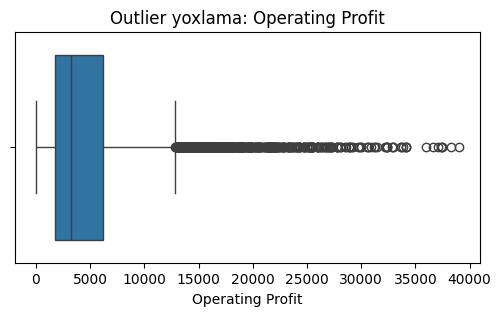

Operating Profit sütununda 694 dənə outlier tapıldı.


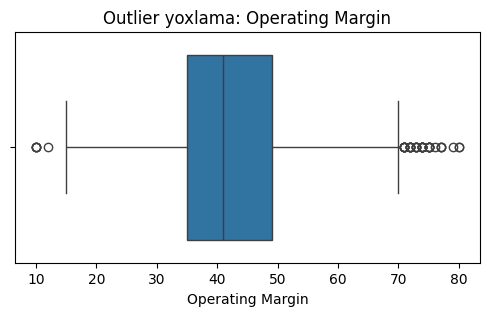

Operating Margin sütununda 44 dənə outlier tapıldı.


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit', 'Operating Margin']

for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Outlier yoxlama: {col}')
    plt.show()

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col} sütununda {outliers.shape[0]} dənə outlier tapıldı.")

    # df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


# **EDA**

In [14]:
df.groupby("Product")["Units Sold"].sum().sort_values(ascending=False).head(10)
#en cox satilan mehsullar

,Units Sold
Product,
Men's Street Footwear,593320
Men's Athletic Footwear,435526
Women's Apparel,433827
Women's Street Footwear,392269
Women's Athletic Footwear,317236
Men's Apparel,306683


In [15]:
df.groupby("Region")["Total Sales"].sum().sort_values(ascending=False)
#regionlara gore umumi satish

,Total Sales
Region,
West,36436157.0
Northeast,25078267.0
Southeast,21374436.0
South,20603356.0
Midwest,16674434.0


In [16]:
df.groupby("Sales Method")["Total Sales"].sum()
#methodlara gore umumi satish

,Total Sales
Sales Method,
In-store,35664375.0
Online,44965657.0
Outlet,39536618.0


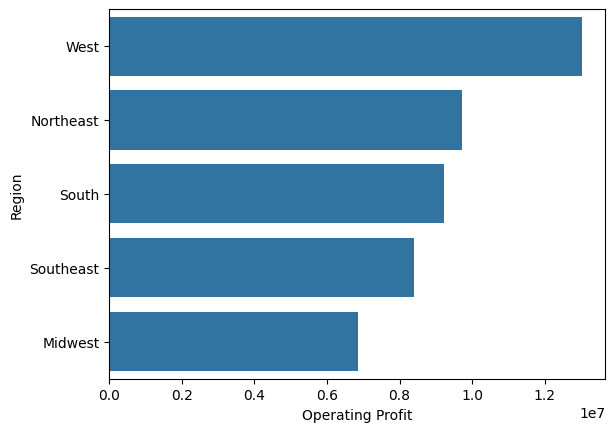

In [20]:
region_sales = df.groupby("Region")["Operating Profit"].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.values, y=region_sales.index)
plt.xlabel("Operating Profit")
plt.ylabel("Region")
plt.show()

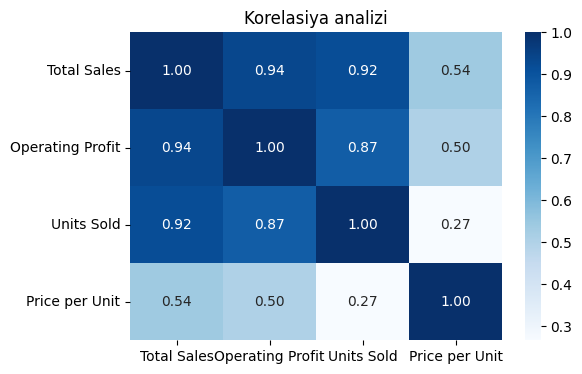

In [19]:

corr = df[["Total Sales", "Operating Profit", "Units Sold", "Price per Unit"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")  # cmap-i Blues olaraq dəyişdik
plt.title("Korelasiya analizi")
plt.show()
